In [1]:
# Add import 
import sys
import torch 
from torch import nn
from torch import optim
import tqdm
import numpy as np
import matplotlib.pyplot as plt
# allow reload of python modules
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy
from dataset import RobotPathDataset
from model.loss import WeightedLoss, ObstacleFreePathLoss

In [2]:
normalizer = MinMaxFeatureNormalizer()
encoder_normalizer = MinMaxFeatureNormalizer()
CONFIG = {
    # Model configuration
    'representation_dim': 64,
    # Hyperparameters for training
    'batch_size': 32,
    'num_epochs': 100,
    'learning_rate': 0.001,
    'optimizer': optim.Adam,
    # Hyperparameters for diffusion process
    'noise_steps': 100,
    'normalize': True,
    'normalizer':normalizer,
    'encoder_normalizer':encoder_normalizer,
    'scheduler': optim.lr_scheduler.ExponentialLR,
    'ema': EMA(0.99),
    'scheduler_gamma': 0.999,

    # Dataset specific configuration
    'n_paths_per_world': 100,
    'n_worlds': 1,
    'n_waypoints': 20,
}

In [3]:
file = 'D:\Desktop\ADLR\RobotPathData\data\SingleSphere02_all.db'
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'],  n_waypoints=CONFIG['n_waypoints'],   normalizer=CONFIG['normalizer'])
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples')
indx_sample = 5
sample = dataset[indx_sample]

world_indx: 0, world_distance_field_images: torch.Size([64, 64])
data shape: torch.Size([1000, 20, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0'), n_worlds:1, samples: 1000
 sample shape torch.Size([20, 2]) with 1000 samples


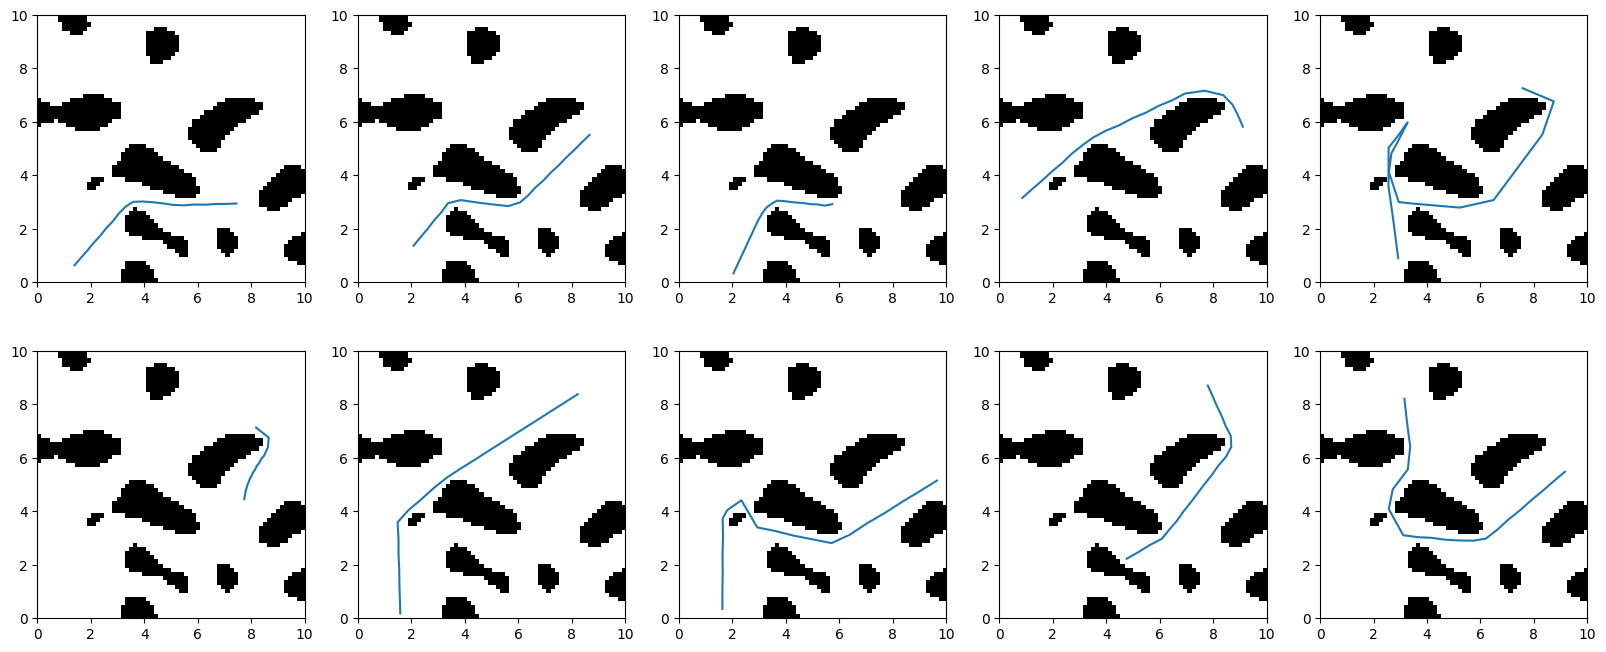

In [4]:
# plot 10 random index samples
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i in range(2):
    for j in range(5):
        indx = np.random.randint(len(dataset))
        sample = dataset[indx]
        sample['path'] = CONFIG['normalizer'].denormalize(sample['path']).cpu().numpy()
        sample['world_img'] = sample['world_img']
        axs[i, j].plot(sample['path'][:, 0], sample['path'][:, 1])
        axs[i, j].imshow(sample['world_img'].T, extent=[0, 10, 0, 10], origin='lower', cmap='binary')


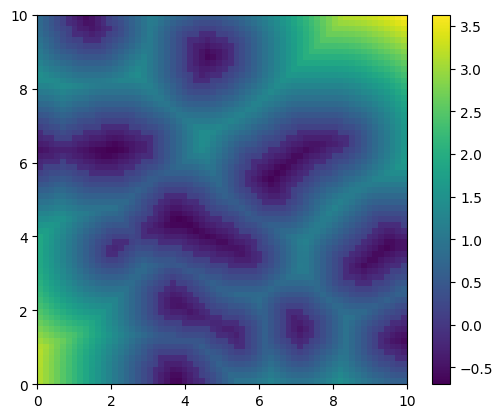

In [5]:
sample = dataset[indx]
dimg = sample['world_distance_field_img']
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
# show the value of colors 
plt.colorbar()

In [6]:
dimg

tensor([[3.1250, 3.1250, 3.1250,  ..., 0.7967, 0.7812, 0.7812],
        [2.9688, 2.9688, 2.9688,  ..., 0.6442, 0.6250, 0.6250],
        [2.8125, 2.8125, 2.8125,  ..., 0.4941, 0.4688, 0.4688],
        ...,
        [0.6442, 0.4941, 0.3494,  ..., 3.2174, 3.3548, 3.4939],
        [0.6250, 0.4688, 0.3125,  ..., 3.2850, 3.4268, 3.5665],
        [0.6250, 0.4688, 0.3125,  ..., 3.3548, 3.4939, 3.6343]])

## Analyse nature of dimg

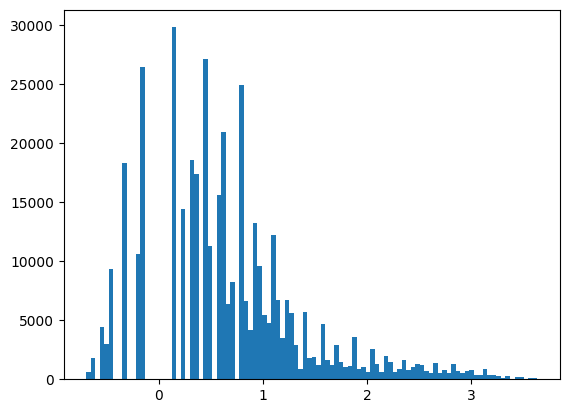

In [7]:
# get hostogram of values 
# sample many points from the dataset
values = []
for i in range(100):
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img']
    values.extend(dimg.flatten());
plt.hist(values, bins=100);

In [8]:
normalizer = MinMaxFeatureNormalizer()
# min_values are a 64 * 64 array filled with -1
min_values = np.ones((64, 64)) * -1
# max_values are a 64 * 64 array filled with 3.5
max_values = np.ones((64, 64)) * 3.5
normalizer.initialize(min_values=min_values, max_values=max_values)

C:\Users\karim lotfy\AppData\Local\Temp\ipykernel_17112\3545446736.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dimg = torch.tensor(dimg, device='cuda').float()


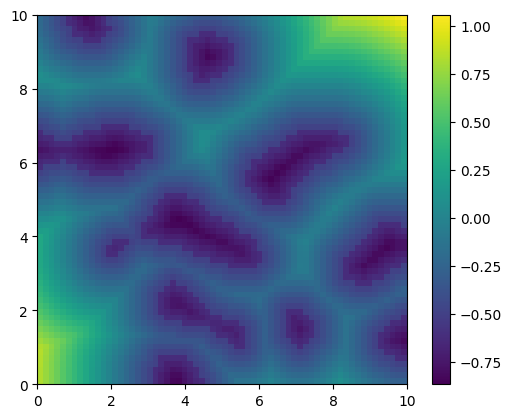

In [9]:
# try to normalize the values using torch layernorm
dimg = torch.tensor(dimg, device='cuda').float()
dimg = normalizer.normalize(dimg)
dimg = dimg.flatten()
dimg = dimg.reshape(64, 64)
plt.imshow(dimg.cpu().detach().numpy().T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.colorbar()

C:\Users\karim lotfy\AppData\Local\Temp\ipykernel_17112\909360617.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dimg = torch.tensor(dimg, device='cuda').float()


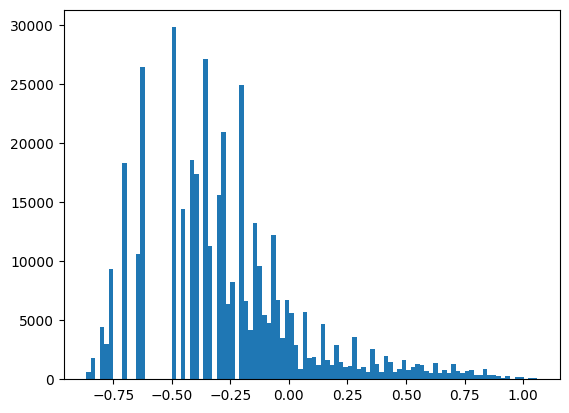

In [10]:
# get hostogram of values 
# sample many points from the dataset
values = []
for i in range(100):
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img']
    # try to normalize the values using torch layernorm
    dimg = torch.tensor(dimg, device='cuda').float()
    dimg = normalizer.normalize(dimg)
    dimg = dimg.flatten()
    dimg = dimg.cpu().detach().numpy()
    values.extend(dimg);
plt.hist(values, bins=100);

C:\Users\karim lotfy\AppData\Local\Temp\ipykernel_17112\3981840068.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dimg = torch.tensor(dimg).float()


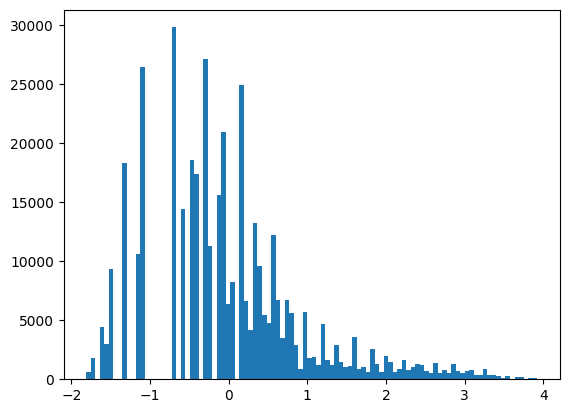

In [11]:
# get hostogram of values 
# sample many points from the dataset
values = []
for i in range(100):
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img']
    # try to normalize the values using torch layernorm
    dimg = torch.tensor(dimg).float()
    norm = nn.LayerNorm(dimg.shape)
    dimg = norm(dimg)
    dimg = dimg.flatten()
    dimg = dimg.cpu().detach().numpy()
    values.extend(dimg);
plt.hist(values, bins=100);

112


C:\Users\karim lotfy\AppData\Local\Temp\ipykernel_17112\3408578164.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


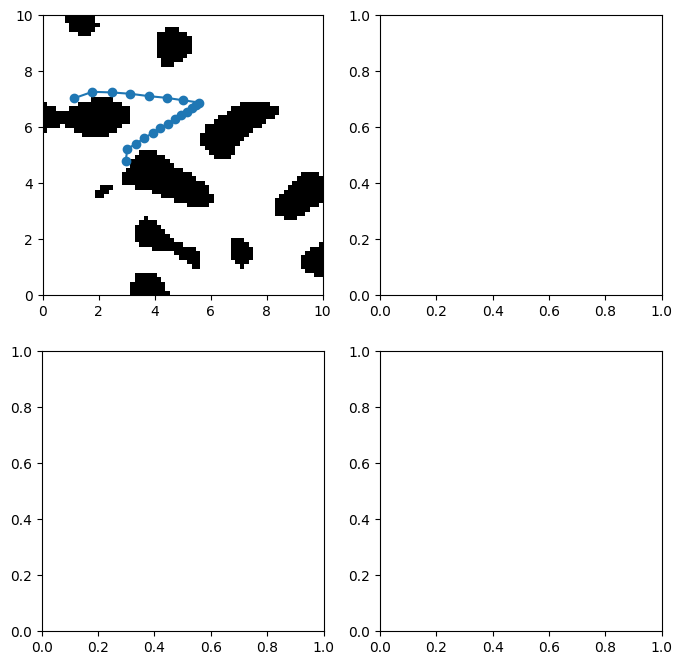

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
indx = 112
print(indx)
sample = dataset[indx]
sample['path'] = CONFIG['normalizer'].denormalize(sample['path']).cpu().numpy()
sample = dataset.get_og_item(indx)
sample['path'] = sample['path'].cpu().numpy()
sample['world_img'] = sample['world_img']
axs[0, 0].plot(sample['path'][:, 0], sample['path'][:, 1], '-o')
axs[0, 0].imshow(sample['world_img'].T, extent=[-0, 10, -0, 10], origin='lower', cmap='binary')
fig.show()

# NEW LOSS FUNCTION

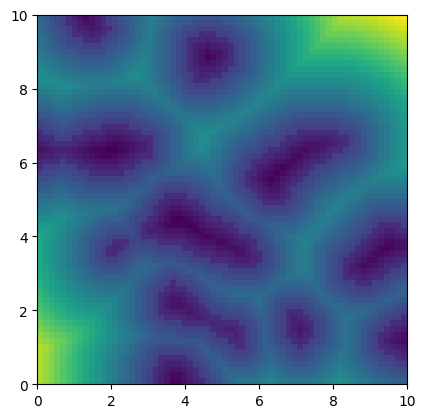

In [13]:
indx = np.random.randint(len(dataset))
# get a random sample 
sample = dataset[indx]
dimg = sample['world_distance_field_img']
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')

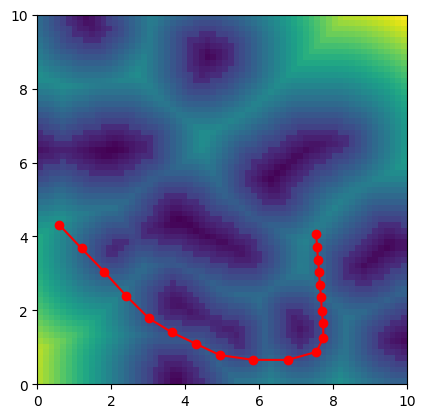

In [14]:
# draw path on top of the distance field
path = sample['og_path'].cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path[:, 0], path[:, 1], '-o', color='red')

In [15]:
loss = ObstacleFreePathLoss(normalizer=None)
indx = np.random.randint(len(dataset))
sample = dataset[indx]
dimg = sample['world_distance_field_img'].to('cuda')
path = sample['og_path']
path = path.unsqueeze(0)
dimg = dimg.unsqueeze(0)
l = loss(path, dimg)
l

tensor(-0.0500, device='cuda:0')

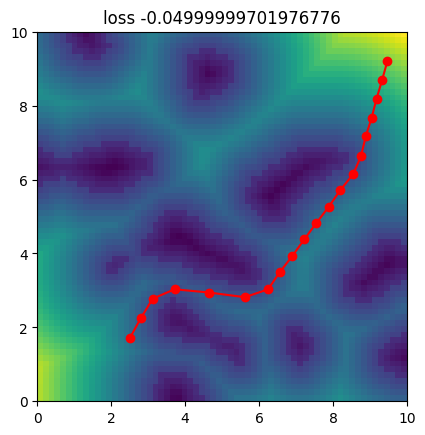

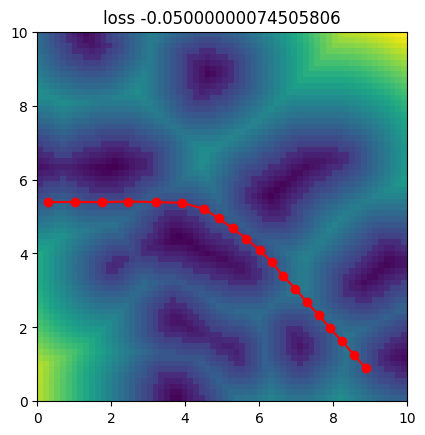

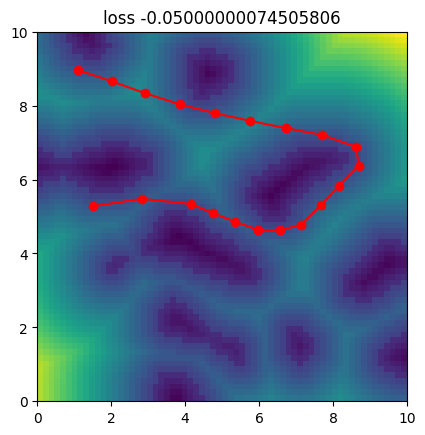

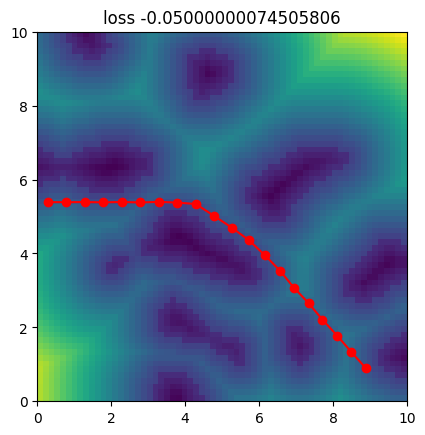

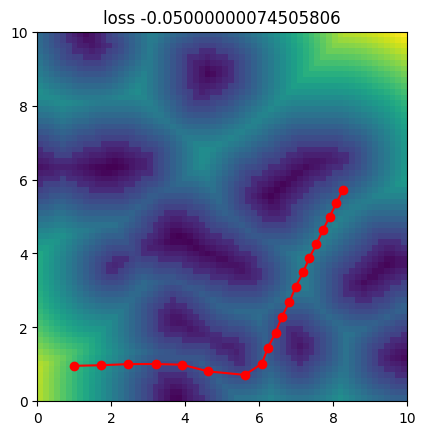

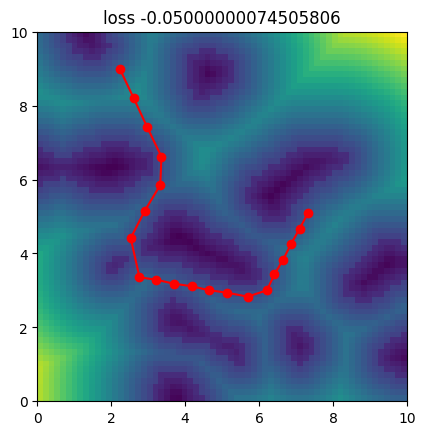

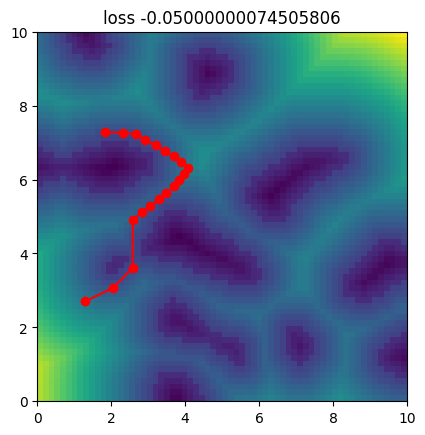

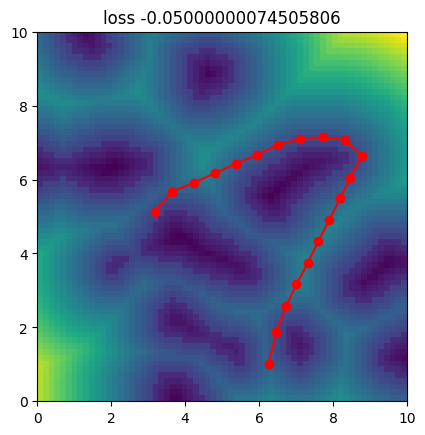

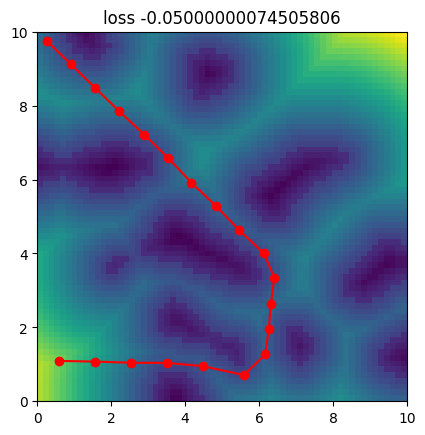

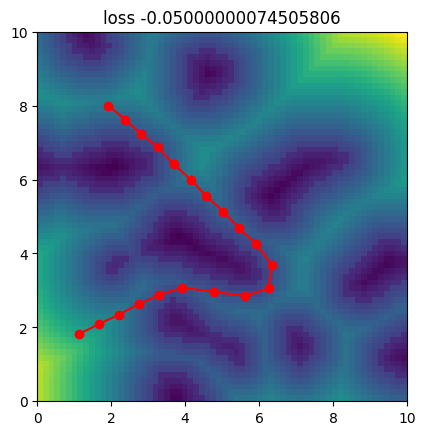

In [16]:
for i in range(10): # plot 10 paths and their distance field
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = loss(path, dimg)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    plt.plot(path[:, 0], path[:, 1], '-o', color='red')
    plt.title(f'loss {l}')
    plt.show()

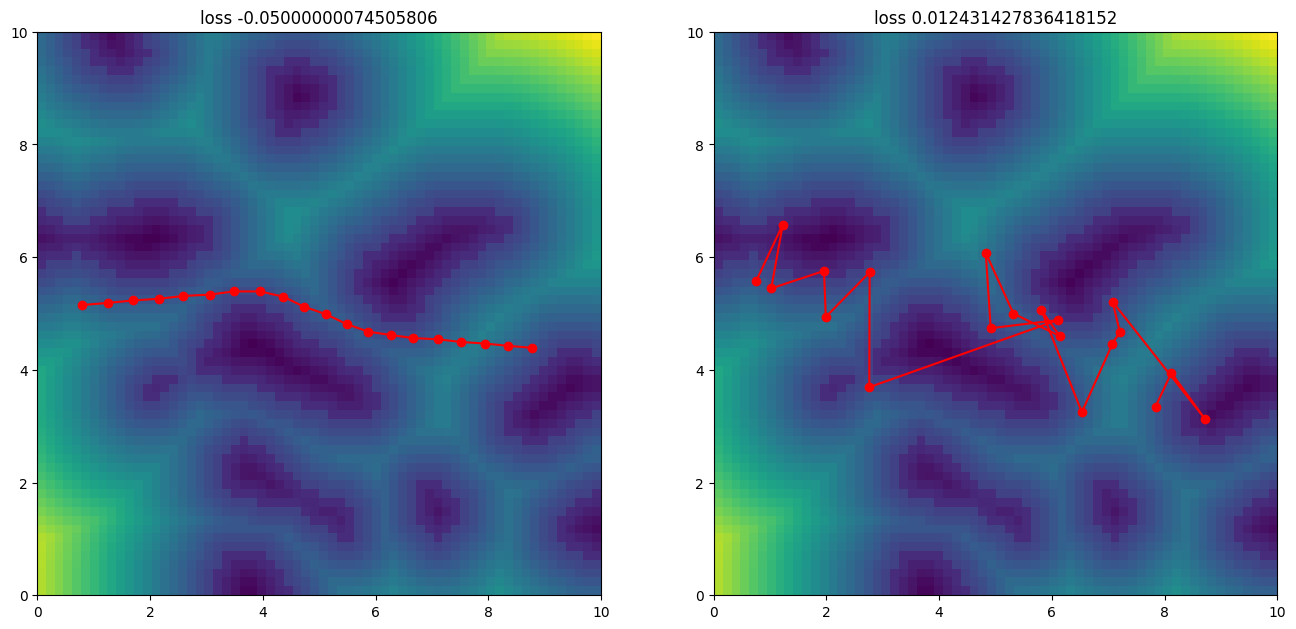

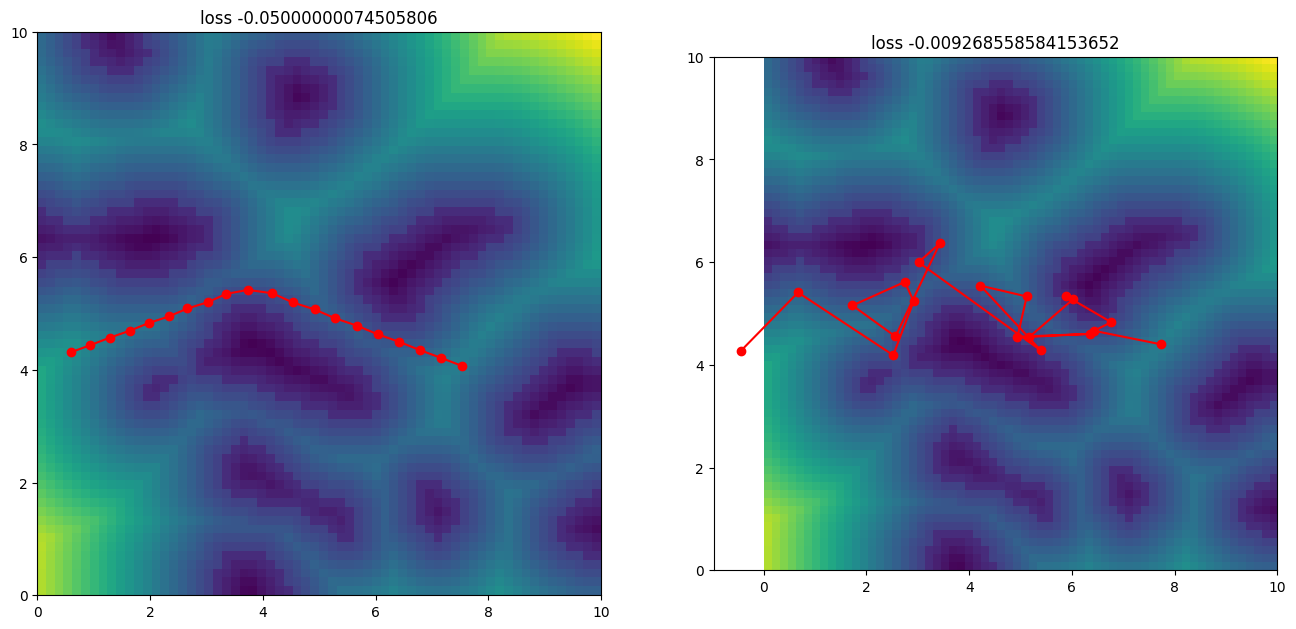

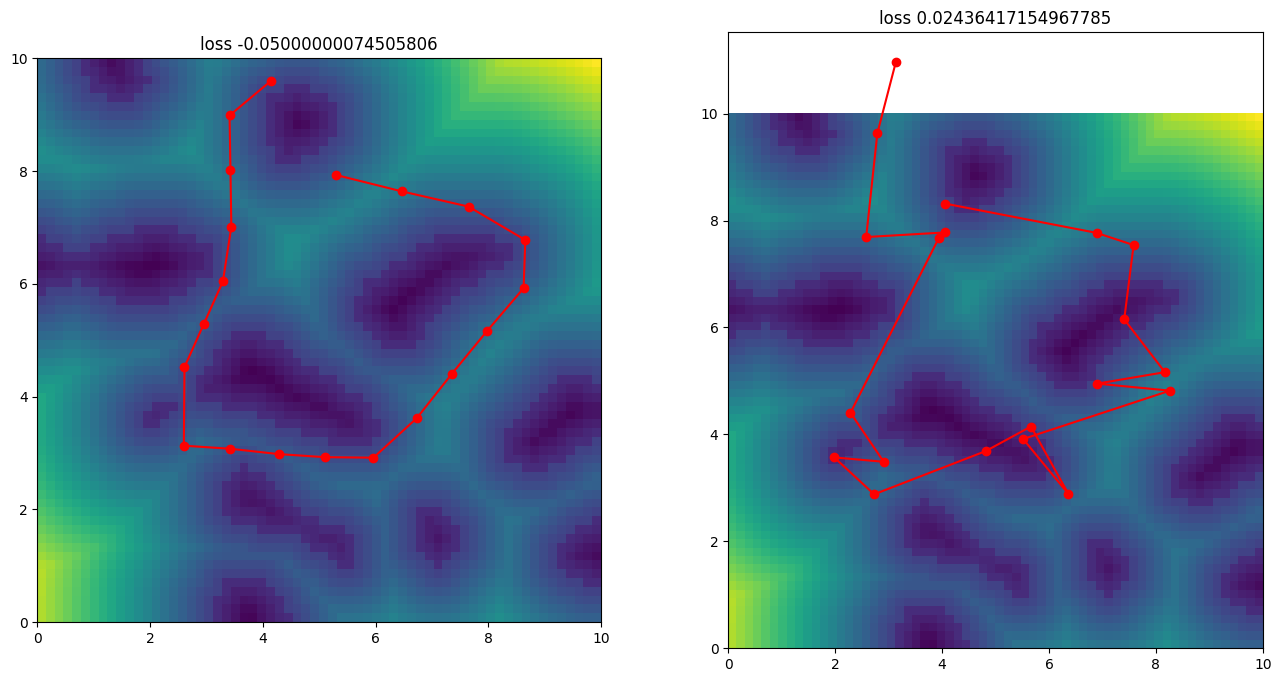

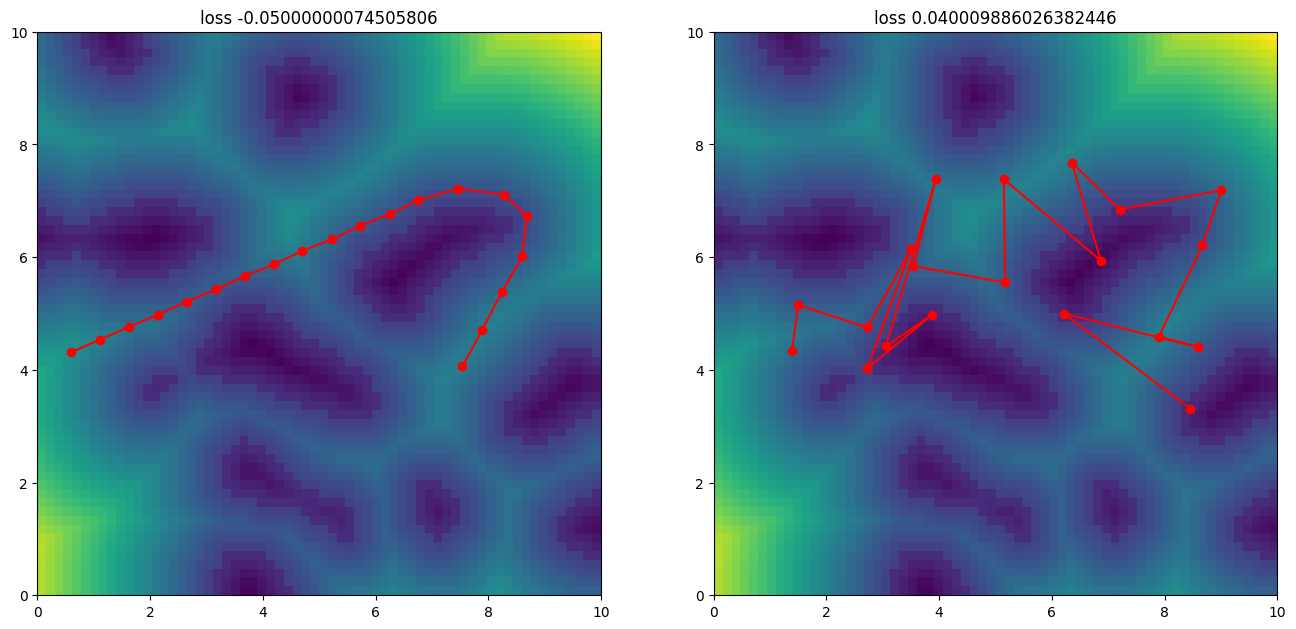

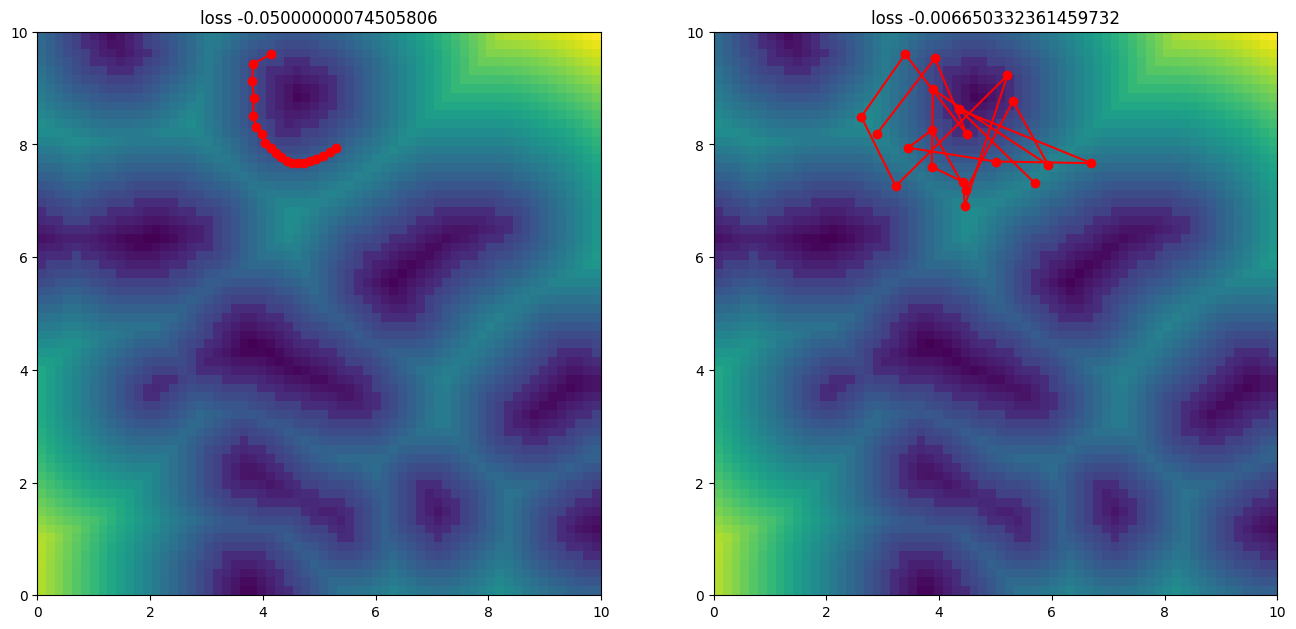

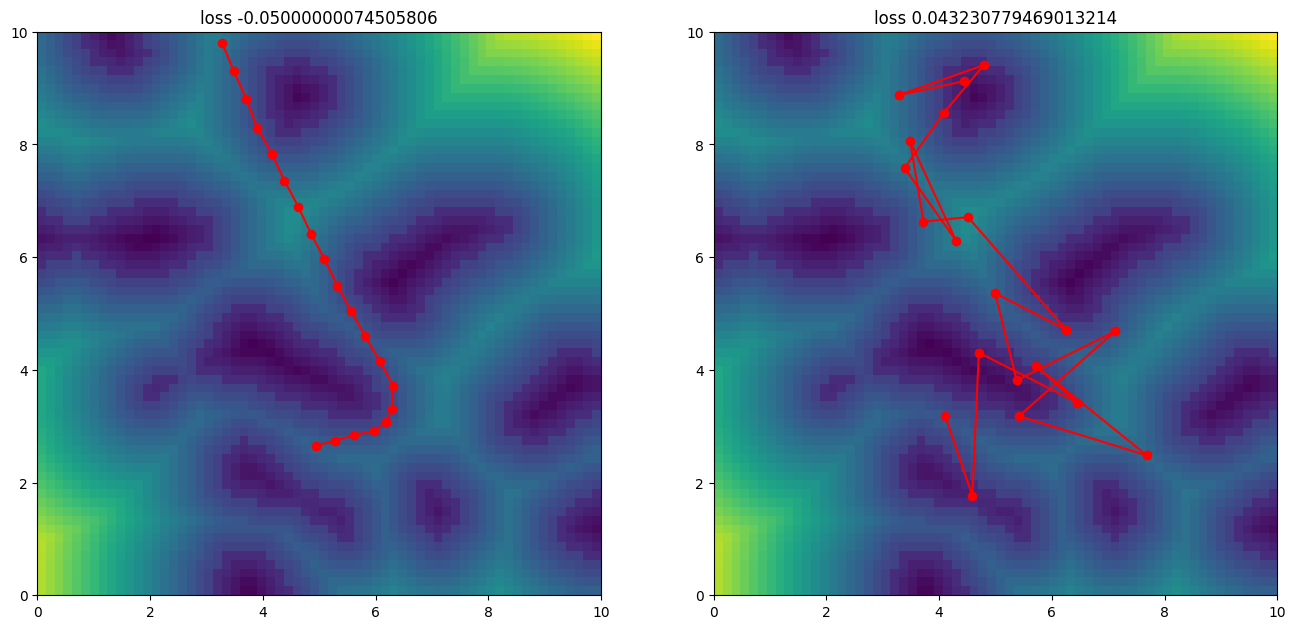

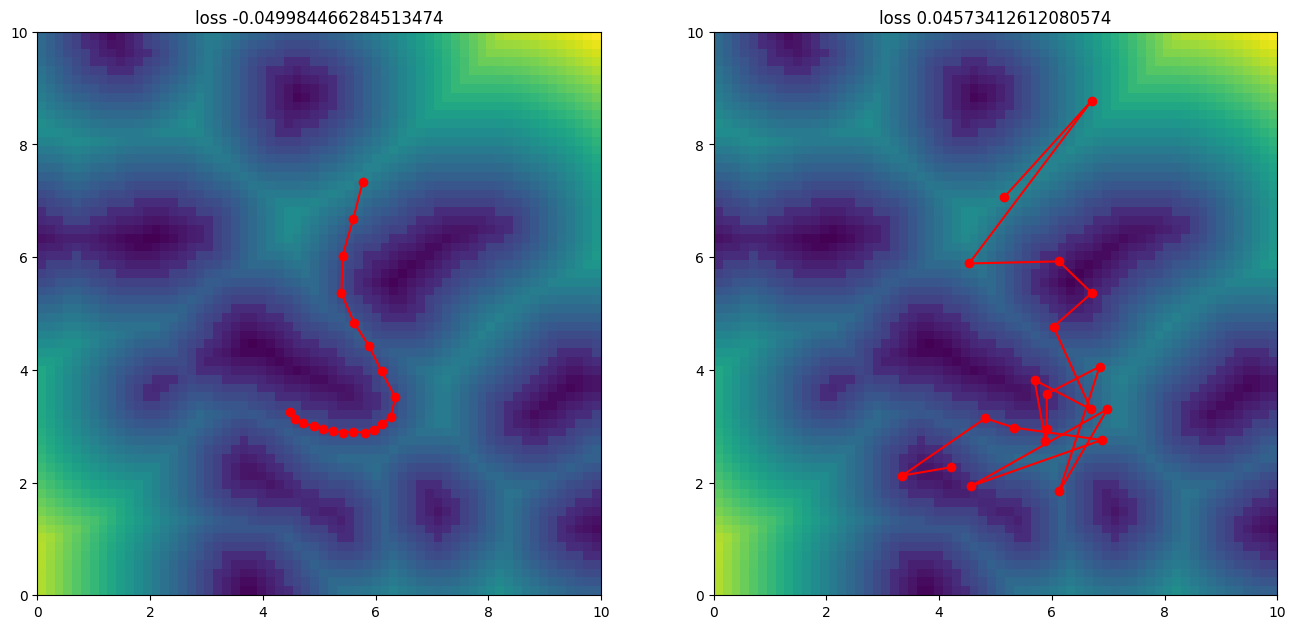

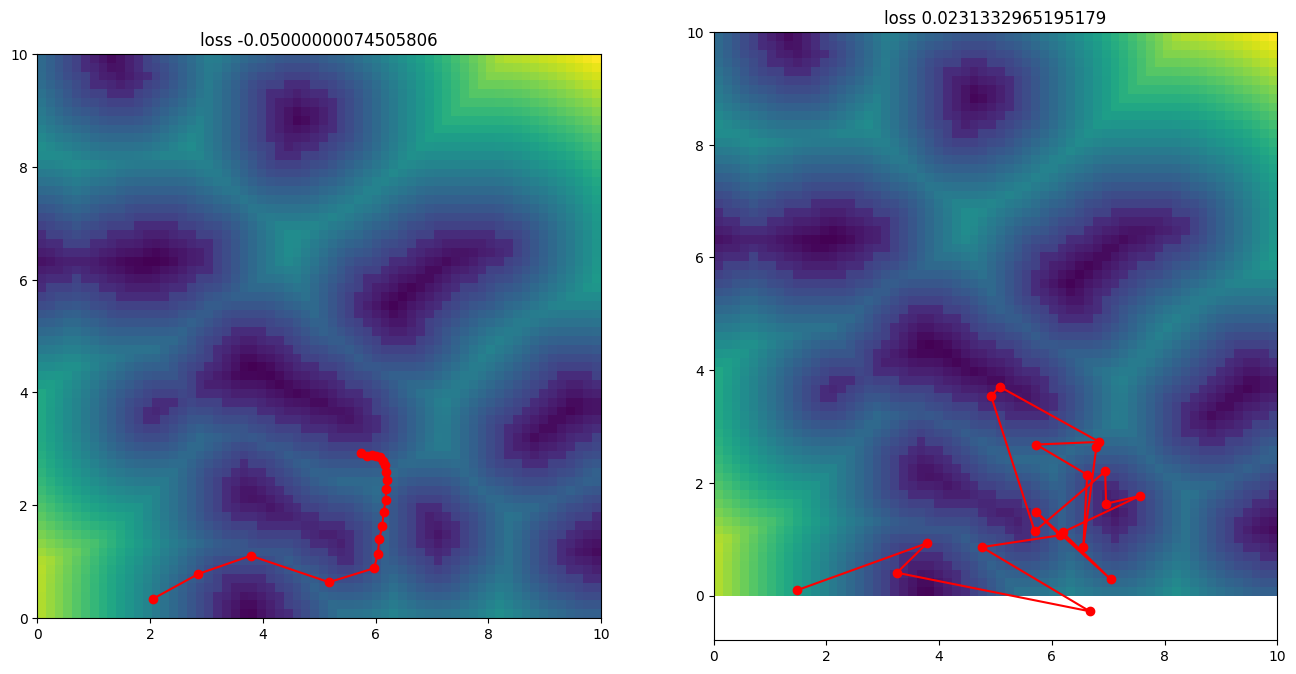

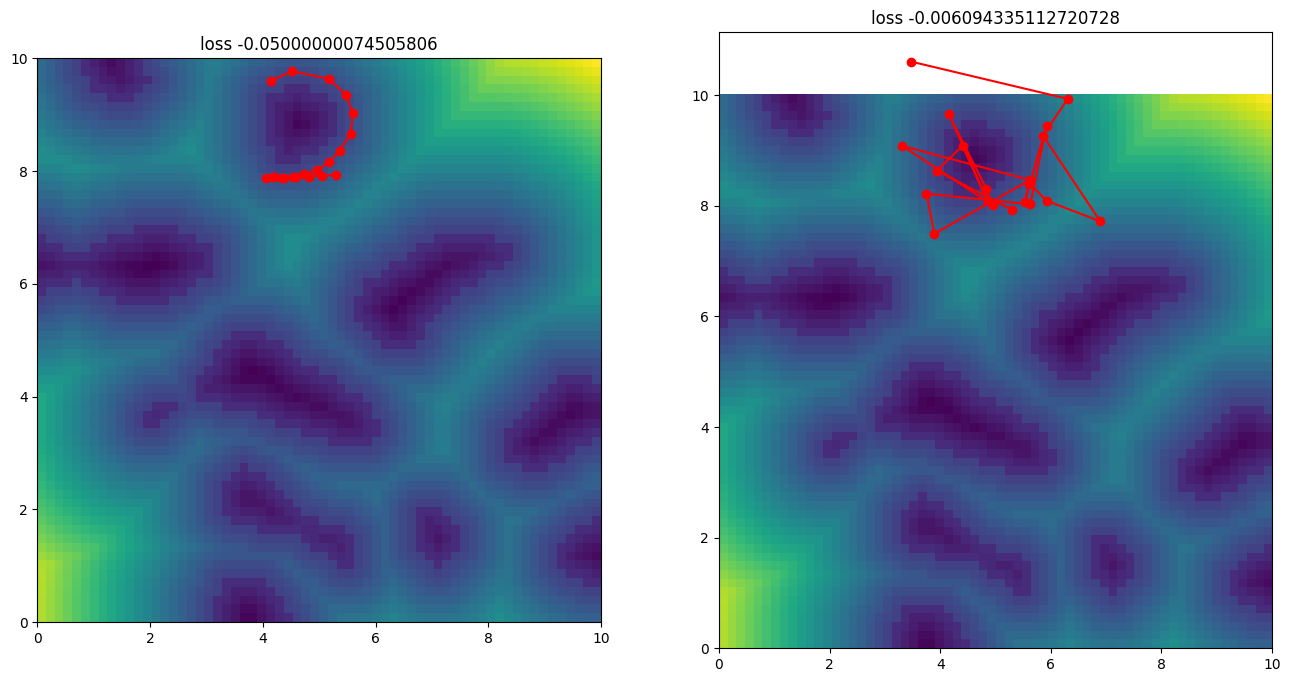

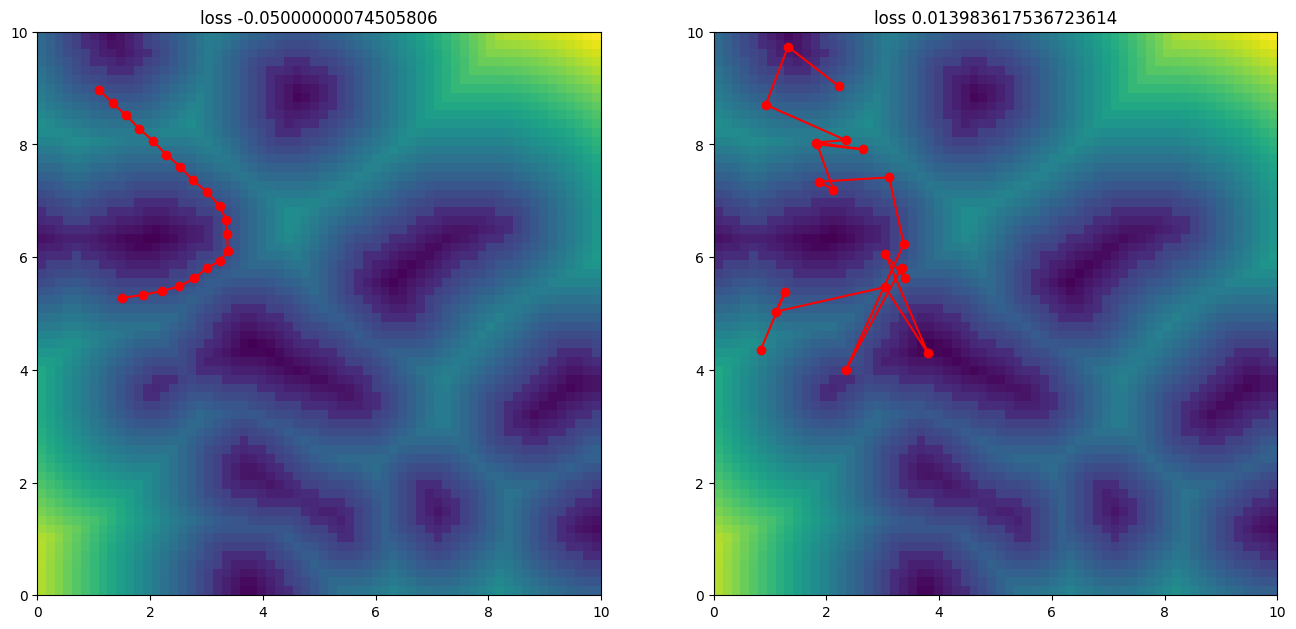

In [17]:
for i in range(10):
    # create a subpolt for 2 graphs
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    # the 1st will be the path and its distance field + loss value 
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = loss(path, dimg)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    axs[0].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[0].plot(path[:, 0], path[:, 1], '-o', color='red')
    axs[0].set_title(f'loss {l}')
    # the 2nd will be the path + some noise and its distance field + loss value
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    noise = torch.randn_like(path) * 0.8
    path = path + noise
    l = loss(path, dimg)
    dimg = sample['world_distance_field_img']
    path = path.cpu().detach().numpy()
    axs[1].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[1].plot(path[0, :, 0], path[0, :, 1], '-o', color='red')
    axs[1].set_title(f'loss {l}')

Text(0.5, 1.0, 'loss 0.5834447145462036')

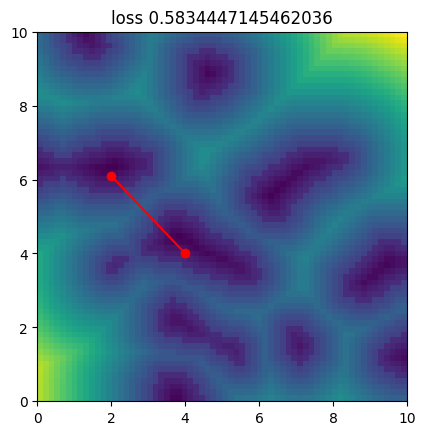

In [48]:

# create my own 2 point path
path = torch.tensor([[2, 6.1], [4, 4]], device='cuda').float()
path = path.unsqueeze(0)
path.requires_grad = True
dimg = sample['world_distance_field_img'].to('cuda')
dimg = dimg.unsqueeze(0)
l = loss(path, dimg)
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'loss {l}')

Text(0.5, 1.0, 'path after optimization')

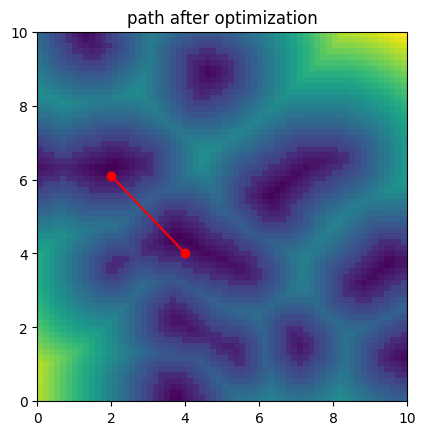

In [49]:
# show the path after the optimization
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'path after optimization')

In [56]:
# take 100 steps of optimization
optimizer = optim.Adam([path], lr=0.01)
for i in range(100):
    dimg = sample['world_distance_field_img'].to('cuda')
    dimg = dimg.unsqueeze(0)
    l = loss(path, dimg)
    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    if i % 10 == 0:
        print(f'loss {l}')

loss 0.43640798330307007
loss 0.35293203592300415
loss 0.32588037848472595
loss 0.1929040551185608
loss 0.14963124692440033
loss -0.008996836841106415
loss -0.05000000447034836
loss -0.05000000074505806
loss -0.05000000074505806
loss -0.04999999701976776


In [57]:
path

tensor([[[1.1342, 5.4707],
         [3.1558, 3.4498]]], device='cuda:0', requires_grad=True)

Text(0.5, 1.0, 'path after optimization')

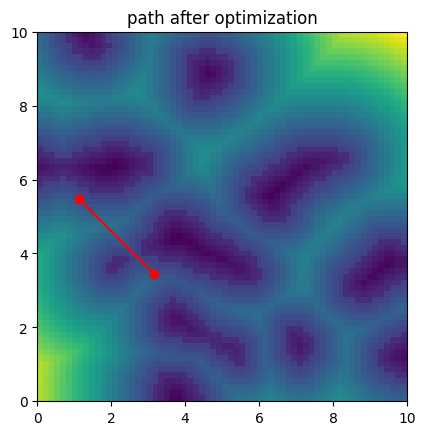

In [58]:
# show the path after the optimization
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'path after optimization')

In [89]:
path = torch.tensor([[2, 6.1], [4, 4]], device='cuda').float()
path = path.unsqueeze(0)
path.requires_grad = True
path_true_points = torch.tensor([[[4, 8], [6.5, 4.5]]], device='cuda').float()


In [96]:
# take 100 steps of optimization
optimizer = optim.Adam([path], lr=0.01)
for i in range(100):
    dimg = sample['world_distance_field_img'].to('cuda')
    dimg = dimg.unsqueeze(0)
    l1 = loss(path, dimg)
    l2 = nn.MSELoss()(path, path_true_points)
    l = l1 + l2
    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    if i % 10 == 0:
        print(f'loss {l}')

loss -0.04982274770736694
loss -0.049980420619249344
loss -0.04999489709734917
loss -0.04999895766377449
loss -0.049999039620161057
loss -0.04999927431344986
loss -0.04999978840351105
loss -0.04999997466802597
loss -0.04999997466802597
loss -0.04999999701976776


Text(0.5, 1.0, 'path after optimization')

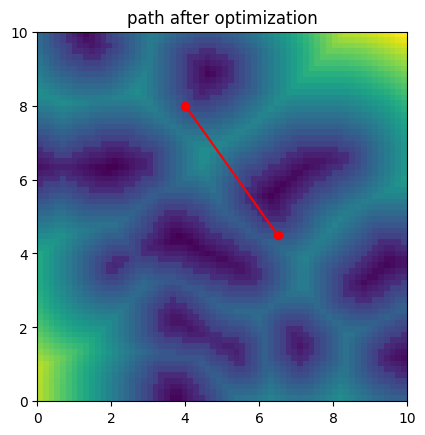

In [97]:
# show the path after the optimization
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'path after optimization')

In [80]:
path

tensor([[[3.9980, 7.0001],
         [6.4982, 4.0000]]], device='cuda:0', requires_grad=True)